<a href="https://colab.research.google.com/github/pedrogebert-jpg/Alimentos_2026/blob/main/semana2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import re

# The output from the previous cell (P3QgE9H0lmsi) contains the data
output_data = "Beatriz Thainara Silveira 17881120 Cristina Pan Motta Oliverio 17884613 Pedro Musseli Gebert 17919635"

# Regular expression to extract names, surnames, and numbers
# It looks for capitalized words (names/surnames) and then a sequence of digits (number)
matches = re.findall(r'([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)\s(\d+)', output_data)

# Prepare the content for README.md
readme_content = "# Registered Users\n\n"
if matches:
    for name_surname, number in matches:
        readme_content += f"- **Name:** {name_surname}, **Number:** {number}\n"
else:
    readme_content += "No data found to register.\n"

# Write the content to README.md
with open('README.md', 'w') as f:
    f.write(readme_content)

print("Content successfully written to README.md")
print("\n--- README.md Content ---")
print(readme_content)

Content successfully written to README.md

--- README.md Content ---
# Registered Users

- **Name:** Beatriz Thainara Silveira, **Number:** 17881120
- **Name:** Cristina Pan Motta Oliverio, **Number:** 17884613
- **Name:** Pedro Musseli Gebert, **Number:** 17919635



In [32]:
import pandas as pd

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Pandas display options set to show all rows and columns.")

Pandas display options set to show all rows and columns.


In [33]:
import pandas as pd

# Load the second Excel file 'dados_semana2.xlsx' into a pandas DataFrame
excel_df_2 = pd.read_excel('/content/dados_semana2.xlsx')

print("Content of 'dados_semana2.xlsx':")
display(excel_df_2)

Content of 'dados_semana2.xlsx':


,Nomes,"Das marcas de chocolate abaixo, qual a sua preferida?",Qual o grau de amargor ideal num chocolate para você?,"Destas marcas, quantas você nunca havia experimentado?","Em média, qual você acha que é a quantidade de chocolate que você consome por dia?"
0,João,Cacau Show,Nada amargo,3,20-30g
1,Isabela,Lindt,Levemente amargo,1,30-40g
2,Márcia,Lindt,Muito amargo,0,30-40g
3,Tereza,Lindt,Amargo,4,50-60g
4,Pedro,Garoto,Amargo,2,80-90g
5,Ceília,Cacau Show,Muito amargo,4,100-110g
6,Roberta,Garoto,Muito amargo,2,130-140g
7,César,Kopenhagen,Nada amargo,2,20-30g
8,Ana,Milka,Nada amargo,6,100-110g
9,Igor,Milka,Nada amargo,7,40-50g


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Certifique-se de que pandas está importado

# Set global font scale for all plots to 3.0x
sns.set(font_scale=3.0)

# Clean column names by stripping whitespace
excel_df_2.columns = excel_df_2.columns.str.strip()

# Explicitly define the mapping from original column names to desired new names.
# This approach is robust because pandas rename will only apply to columns that exist
# and allows for precise mapping regardless of prior partial renames.
explicit_rename_map = {
    'Das marcas de chocolate abaixo, qual a sua preferida?': 'Preferência de Chocolate',
    'Qual o grau de amargor ideal num chocolate para você?': 'Grau de Amargor',
    'Destas marcas, quantas você nunca havia experimentado?': 'Marcas Não Experimentadas',
    'Em média, qual você acha que é a quantidade de chocolate que você consome por dia?': 'Consumo Diário de Chocolate'
}

# Create a final rename map by checking which original names are still present
# and if their target names are not yet set in the DataFrame.
final_rename_map = {
    original_name: target_name
    for original_name, target_name in explicit_rename_map.items()
    if original_name in excel_df_2.columns and target_name not in excel_df_2.columns
}

# Apply renaming if any changes are needed
if final_rename_map:
    excel_df_2.rename(columns=final_rename_map, inplace=True);

# Print columns after rename to verify the changes
print(f"Colunas após renomear: {excel_df_2.columns.tolist()}")

Colunas após renomear: ['Nomes', 'Preferência de Chocolate', 'Grau de Amargor', 'Marcas Não Experimentadas', 'Consumo Diário de Chocolate']





### Gráfico de Pizza 1: Preferência de Marcas de Chocolate




<Figure size 3000x2400 with 0 Axes>

<Figure size 3000x2400 with 0 Axes>

<Figure size 3600x2200 with 0 Axes>

<Figure size 3000x1800 with 0 Axes>

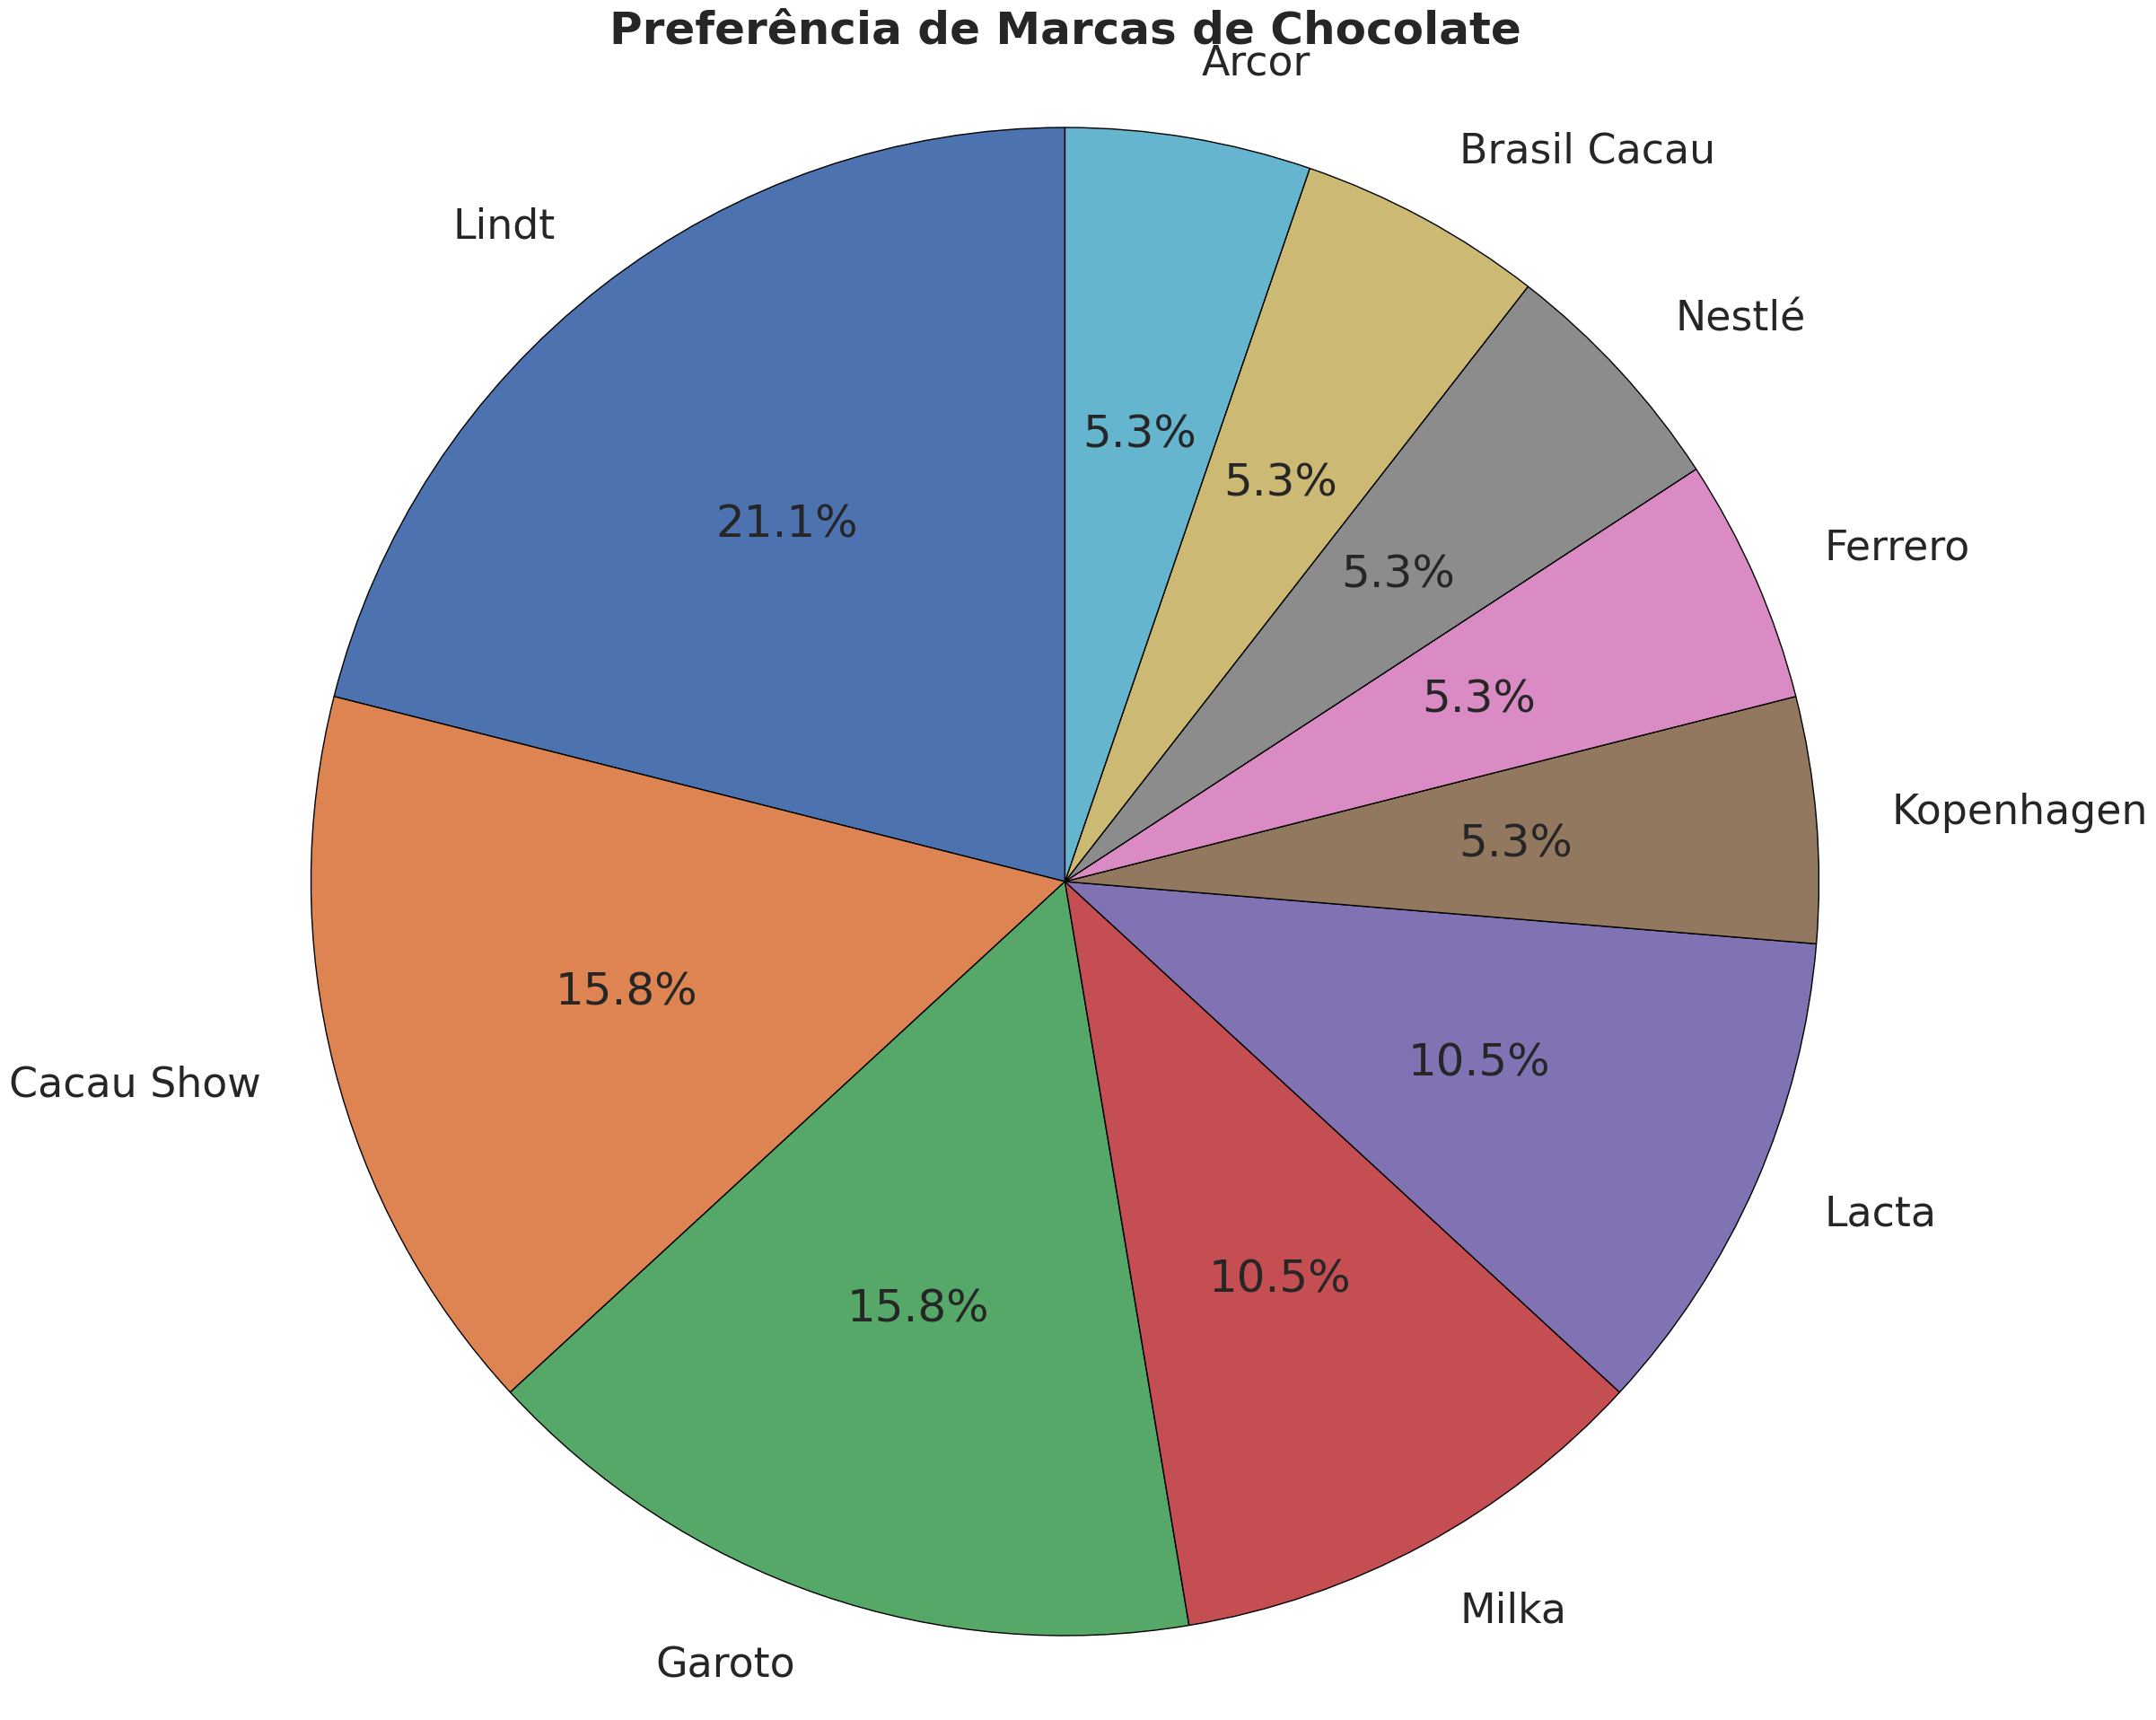

In [39]:
# --- Gráfico de Pizza 1: Preferência de Chocolate ---
plt.figure(figsize=(30, 24)) # Increased figsize for more space
chocolate_pref_counts = excel_df_2['Preferência de Chocolate'].value_counts()
plt.pie(chocolate_pref_counts, labels=chocolate_pref_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Preferência de Marcas de Chocolate', fontweight='bold') # Bold title
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()




### Gráfico de Pizza 2: Grau de Amargor Ideal para Chocolate




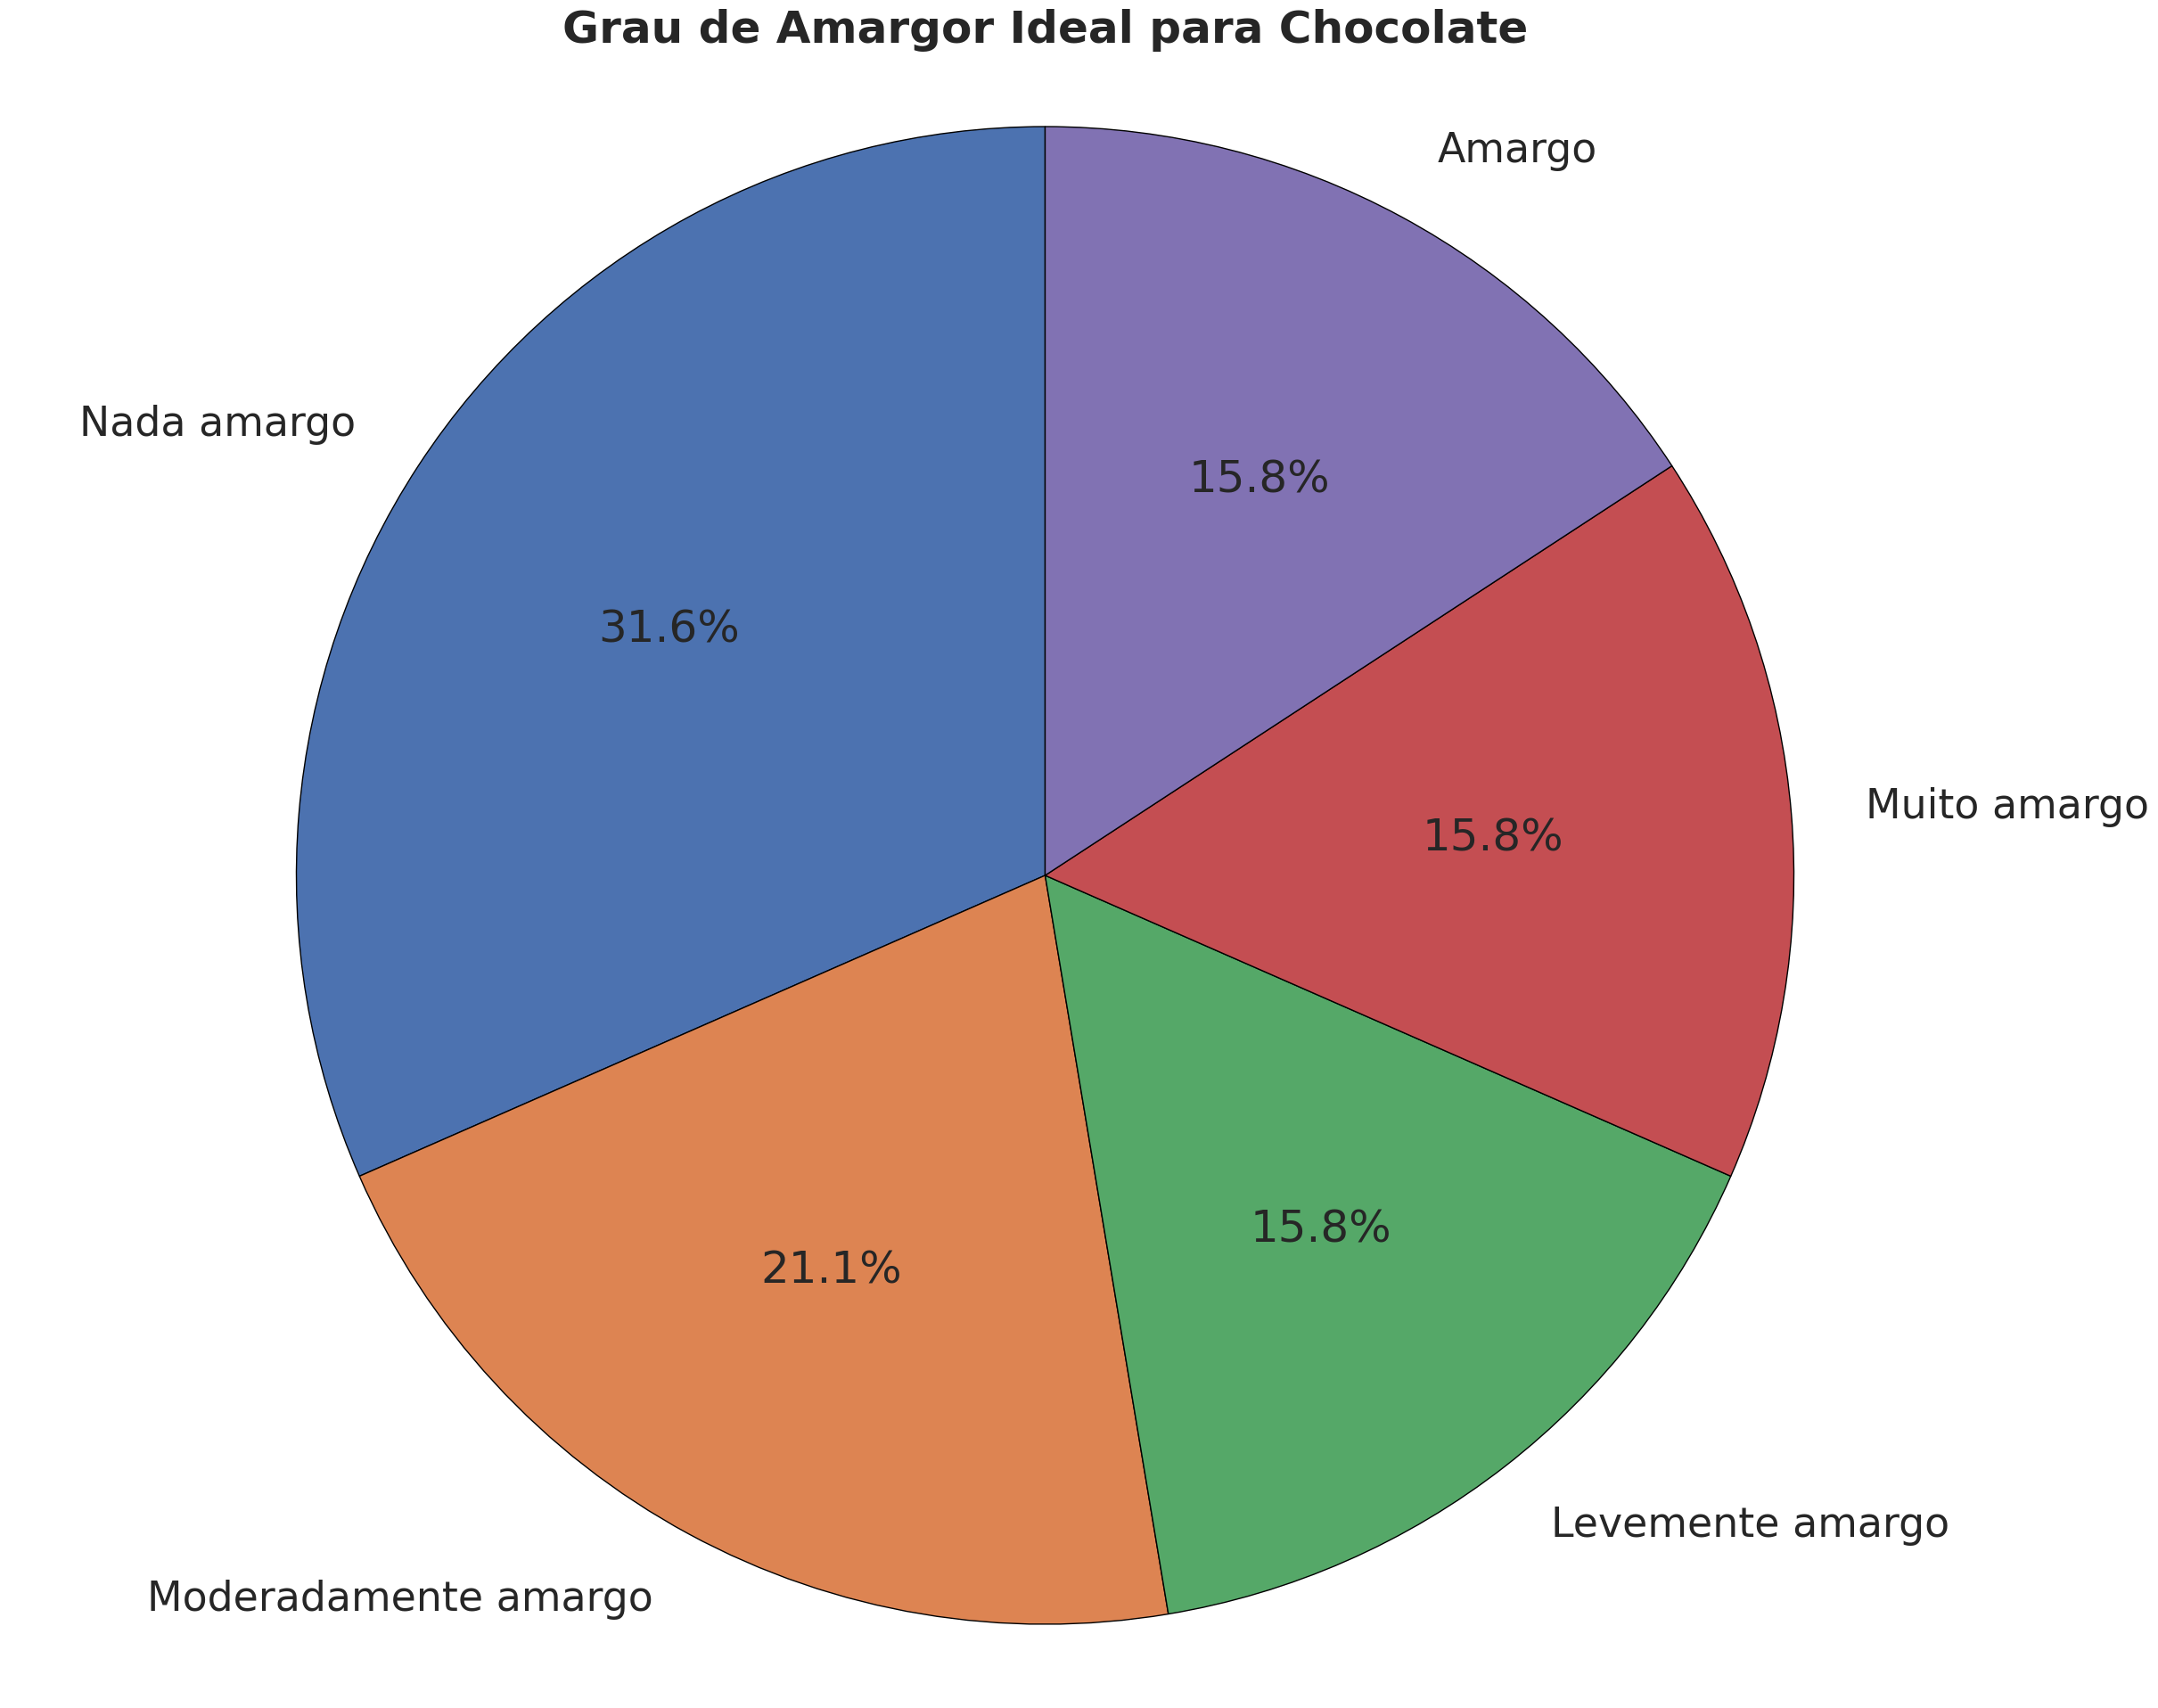

In [40]:
# --- Gráfico de Pizza 2: Grau de Amargor ---
plt.figure(figsize=(30, 24)) # Increased figsize for more space
amargor_counts = excel_df_2['Grau de Amargor'].value_counts()
plt.pie(amargor_counts, labels=amargor_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Grau de Amargor Ideal para Chocolate', fontweight='bold') # Bold title
plt.axis('equal')
plt.show()




### Gráfico de Barras: Quantidade de Marcas de Chocolate Nunca Experimentadas




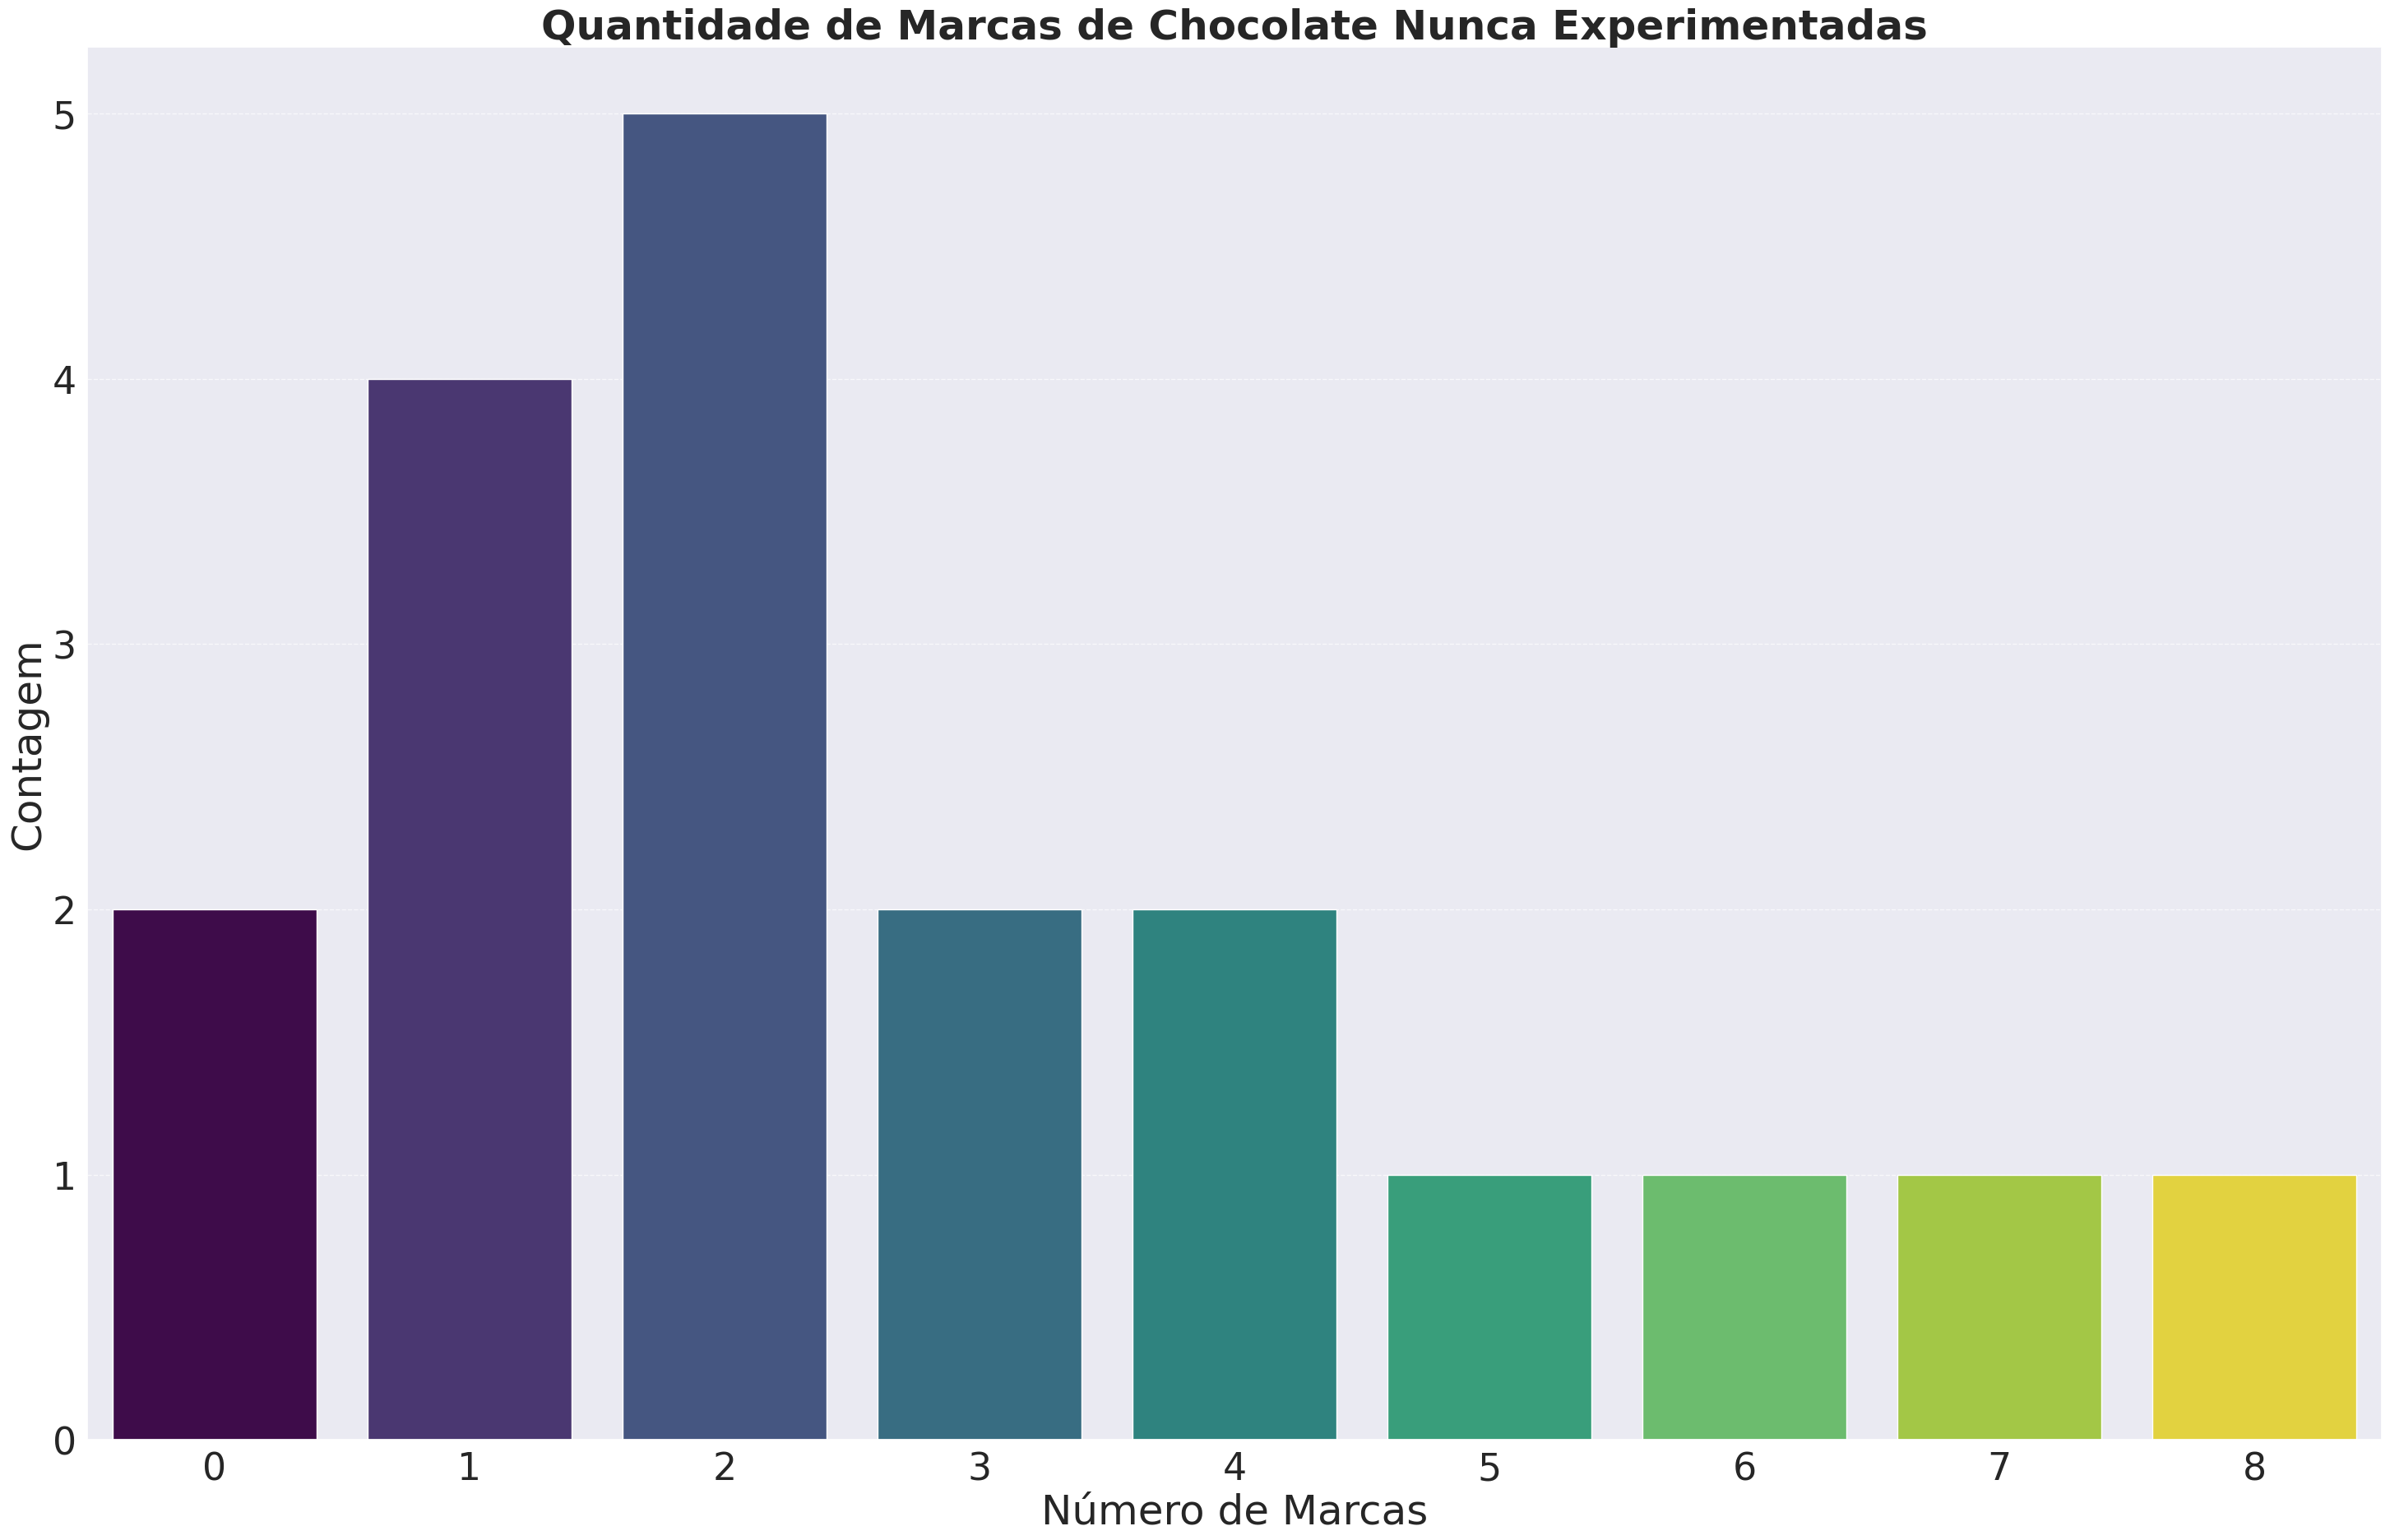

In [41]:
# --- Gráfico de Barras: Marcas Não Experimentadas ---
plt.figure(figsize=(36, 22)) # Increased figsize for more space
sns.countplot(data=excel_df_2, x='Marcas Não Experimentadas', palette='viridis', hue='Marcas Não Experimentadas', legend=False)
plt.title('Quantidade de Marcas de Chocolate Nunca Experimentadas', fontweight='bold') # Bold title
plt.xlabel('Número de Marcas')
plt.ylabel('Contagem')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




### Histograma: Distribuição do Consumo Diário de Chocolate




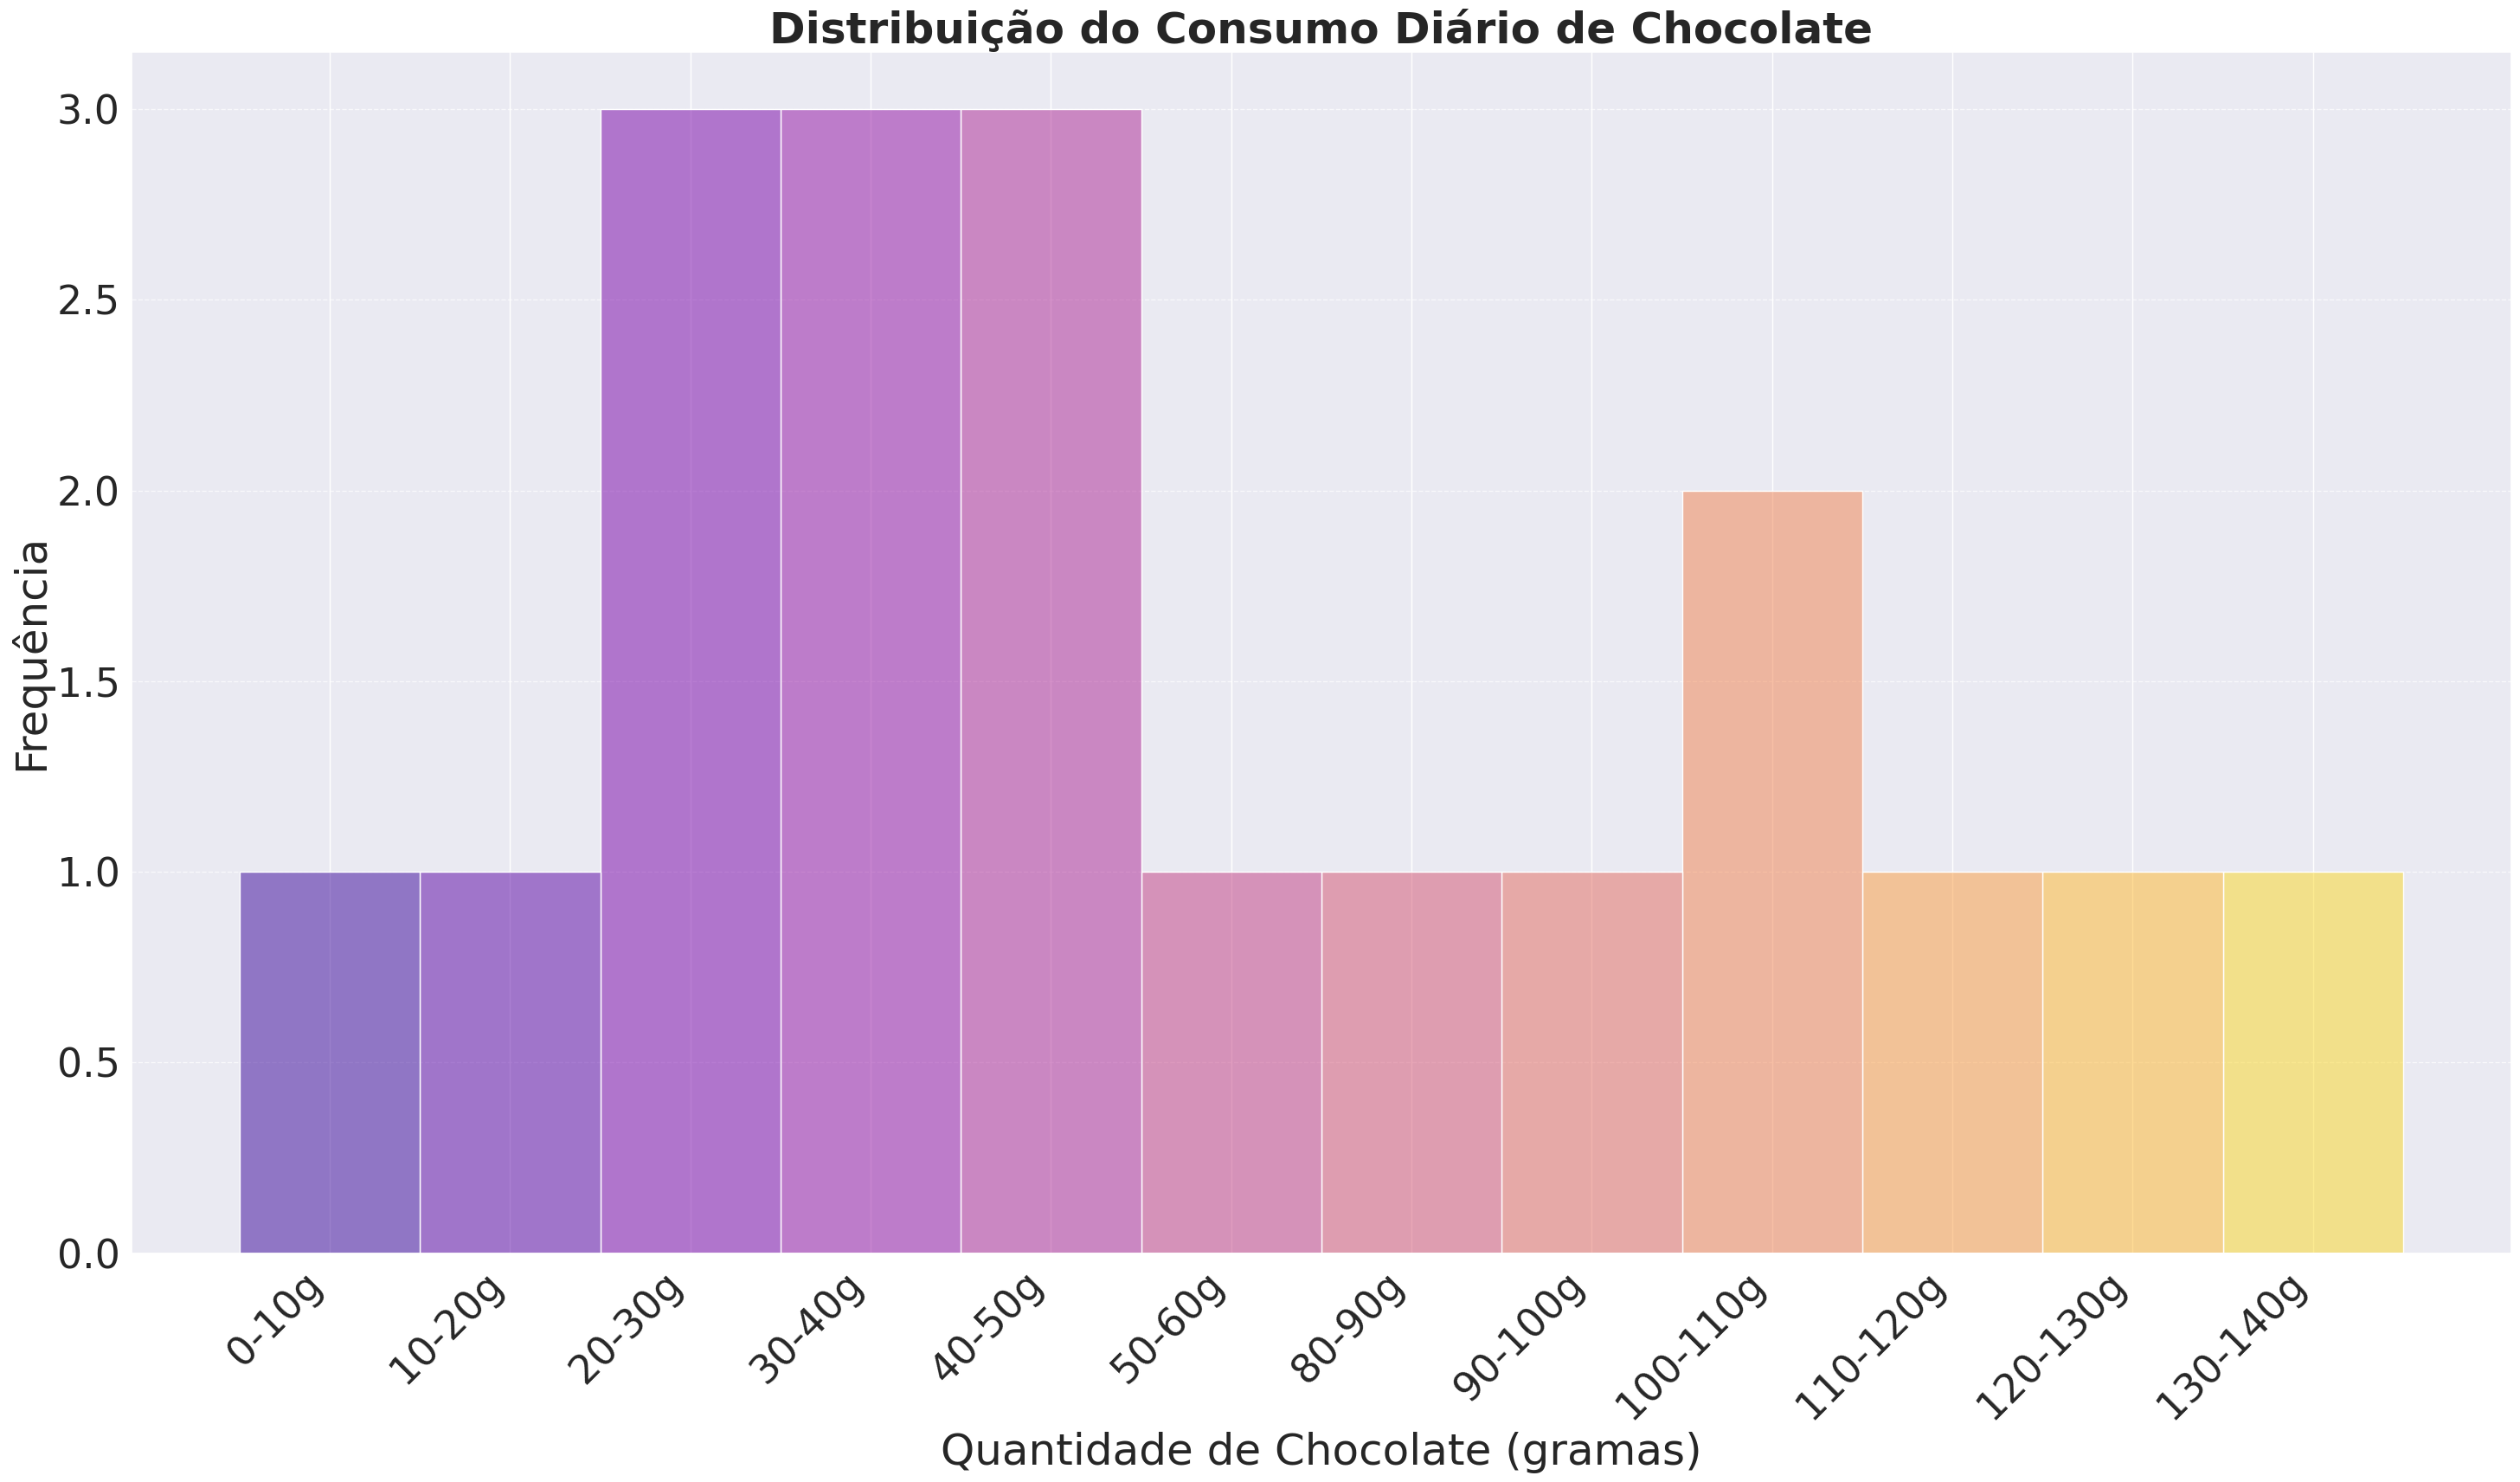

In [42]:
# --- Histograma: Consumo Diário de Chocolate ---
plt.figure(figsize=(30, 18)) # Increased figsize for more space
# Function to extract numerical value for sorting
def get_sort_key(category_string):
    # Handle cases like 'X-Yg'
    if '-' in category_string:
        return int(category_string.split('-')[0])
    # Handle single value cases if they exist (e.g., '10g')
    elif 'g' in category_string:
        # Remove 'g' and then convert to int
        return int(category_string.replace('g', ''))
    return 0 # Default for unexpected formats

# Get unique consumption categories and sort them numerically
unique_consumption_categories = excel_df_2['Consumo Diário de Chocolate'].unique()
sorted_consumption_categories = sorted(list(unique_consumption_categories), key=get_sort_key)

# Convert the column to an ordered Categorical type
excel_df_2['Consumo Diário de Chocolate'] = pd.Categorical(
    excel_df_2['Consumo Diário de Chocolate'],
    categories=sorted_consumption_categories,
    ordered=True
)

sns.histplot(data=excel_df_2, x='Consumo Diário de Chocolate', kde=True, palette='plasma', hue='Consumo Diário de Chocolate', legend=False)
plt.title('Distribuição do Consumo Diário de Chocolate', fontweight='bold') # Bold title
plt.xlabel('Quantidade de Chocolate (gramas)')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()